In [5]:
import pandas as pd
import numpy as np
import umap
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import joblib
import os
# 1. Load Moltbook Data
moltbook = pd.read_pickle("../../data/moltbook_final_mehmeh.pkl")
moltbook.rename(columns={"submolt_name": "forum"}, inplace=True)

# 2. Preprocess Timestamps
moltbook["created_at"] = pd.to_datetime(moltbook["created_at"], utc=True)
moltbook['hour'] = moltbook['created_at'].dt.hour

# 3. One-Hot Encode Forum Category
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(moltbook[['forum']])
feature_names = encoder.get_feature_names_out(['forum'])

encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=moltbook.index)
df_encoded = pd.concat([moltbook, encoded_df], axis=1)

# 4. Filter strictly to Target and Base Features
base_features = ['score', 'comment_existence', 'avg_early_sentiment', 
                 'max_early_sentiment', 'min_early_sentiment', 'hour'] + list(feature_names)

base_features = [col for col in base_features if col in df_encoded.columns]
df_base = df_encoded[base_features]

# 5. Load Raw Moltbook Embeddings
print("Loading Moltbook embeddings...")
moltbook_embedding = np.load('../../data/moltbook_features_full.npy')
emb_df = pd.DataFrame(moltbook_embedding, index=df_base.index)
emb_df.columns = [f'emb_{i}' for i in range(emb_df.shape[1])]

# 6. Prepare Target Variable
target_col = 'score'
y_raw = df_base[target_col].clip(lower=0)
y = np.log1p(y_raw)
X_base = df_base.drop(columns=[target_col])

# 7. Train-Test Split (Splitting Base and Embeddings simultaneously)
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=0.30, random_state=42
)
X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Base Training Shape: {X_base_train.shape}")
print(f"Embeddings Training Shape: {emb_train.shape}")

Loading Moltbook embeddings...
Base Training Shape: (5338, 8)
Embeddings Training Shape: (5338, 1537)


In [6]:
# ==========================================
# MODEL 1: NON-UMAP (Base + Raw Embeddings)
# ==========================================
print("Training Moltbook Model 1: Non-UMAP (Base + Raw Embeddings)...")
X_train_raw = pd.concat([X_base_train, emb_train], axis=1)
X_val_raw = pd.concat([X_base_val, emb_val], axis=1)
X_test_raw = pd.concat([X_base_test, emb_test], axis=1)

model_rf_raw = RandomForestRegressor(
    n_estimators=500, max_depth=6, max_features=0.8, max_samples=0.8, n_jobs=-1, random_state=42
)
model_rf_raw.fit(X_train_raw, y_train)

r2_val_raw = r2_score(y_val, model_rf_raw.predict(X_val_raw))
r2_test_raw = r2_score(y_test, model_rf_raw.predict(X_test_raw))
print(f"Moltbook Non-UMAP R2 Validation: {r2_val_raw:.4f}")
print(f"Moltbook Non-UMAP R2 Test: {r2_test_raw:.4f}")

Training Moltbook Model 1: Non-UMAP (Base + Raw Embeddings)...
Moltbook Non-UMAP R2 Validation: 0.1795
Moltbook Non-UMAP R2 Test: 0.1869


In [7]:


# ==========================================
# MODEL 2: UMAP (Base + UMAP Reduced Embeddings)
# ==========================================
print("Training Moltbook Model 2: UMAP (Base + UMAP Reduced Embeddings)...")
n_components = 50
umap_model_path = '../../data/moltbook_umap_reducer.joblib'

# Check if the UMAP model has already been saved
if os.path.exists(umap_model_path):
    print(f"Loading existing UMAP model from {umap_model_path}...")
    reducer = joblib.load(umap_model_path)
    print("Transforming training embeddings...")
    emb_train_umap = reducer.transform(emb_train)
else:
    print(f"Fitting UMAP (n_components={n_components}) strictly on training embeddings...")
    reducer = umap.UMAP(n_components=n_components, random_state=42)
    emb_train_umap = reducer.fit_transform(emb_train)
    print(f"Saving UMAP model to {umap_model_path}...")
    joblib.dump(reducer, umap_model_path)

print("Transforming validation and test embeddings...")
emb_val_umap = reducer.transform(emb_val)
emb_test_umap = reducer.transform(emb_test)

umap_cols = [f'umap_emb_{i}' for i in range(n_components)]
df_emb_train_umap = pd.DataFrame(emb_train_umap, index=X_base_train.index, columns=umap_cols)
df_emb_val_umap = pd.DataFrame(emb_val_umap, index=X_base_val.index, columns=umap_cols)
df_emb_test_umap = pd.DataFrame(emb_test_umap, index=X_base_test.index, columns=umap_cols)

X_train_umap = pd.concat([X_base_train, df_emb_train_umap], axis=1)
X_val_umap = pd.concat([X_base_val, df_emb_val_umap], axis=1)
X_test_umap = pd.concat([X_base_test, df_emb_test_umap], axis=1)

model_rf_umap = RandomForestRegressor(
    n_estimators=500, max_depth=6, max_features=0.8, max_samples=0.8, n_jobs=-1, random_state=42
)
model_rf_umap.fit(X_train_umap, y_train)

r2_val_umap = r2_score(y_val, model_rf_umap.predict(X_val_umap))
r2_test_umap = r2_score(y_test, model_rf_umap.predict(X_test_umap))
print(f"Moltbook UMAP R2 Validation: {r2_val_umap:.4f}")
print(f"Moltbook UMAP R2 Test: {r2_test_umap:.4f}")

Training Moltbook Model 2: UMAP (Base + UMAP Reduced Embeddings)...
Fitting UMAP (n_components=50) strictly on training embeddings...


c:\Users\Rald999\Anaconda3\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saving UMAP model to ../../data/moltbook_umap_reducer.joblib...
Transforming validation and test embeddings...
Moltbook UMAP R2 Validation: 0.1867
Moltbook UMAP R2 Test: 0.1931


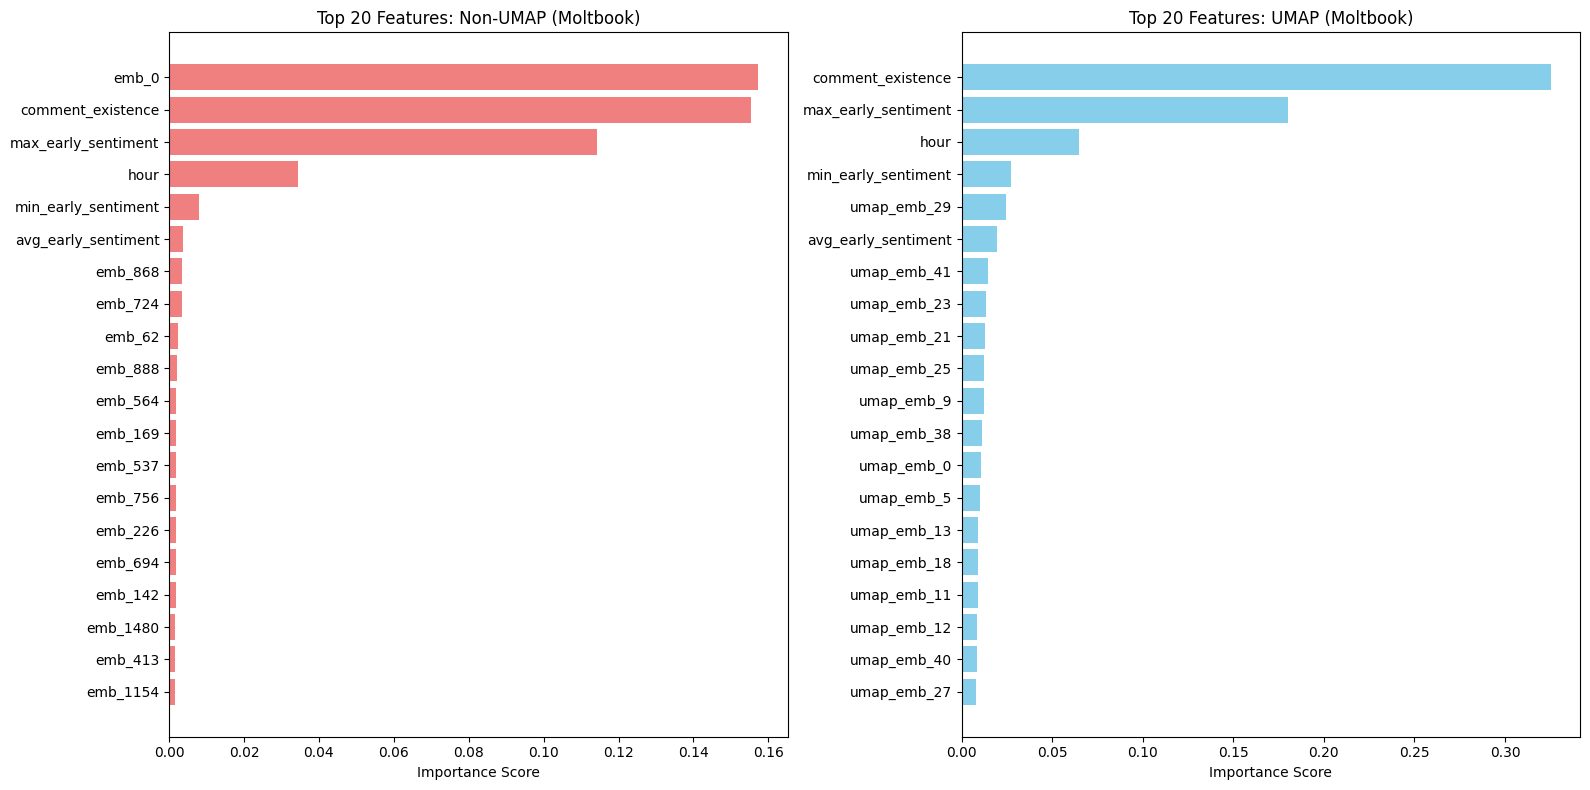

In [8]:
# ==========================================
# VISUALIZE FEATURE IMPORTANCES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_n = 20

# Plot 1: Non-UMAP
importances_raw = model_rf_raw.feature_importances_
df_imp_raw = pd.DataFrame({'Feature': X_train_raw.columns, 'Importance': importances_raw})
df_imp_raw = df_imp_raw.sort_values(by='Importance', ascending=False).head(top_n)
axes[0].barh(df_imp_raw['Feature'][::-1], df_imp_raw['Importance'][::-1], color='lightcoral')
axes[0].set_title(f'Top {top_n} Features: Non-UMAP (Moltbook)')
axes[0].set_xlabel('Importance Score')

# Plot 2: UMAP
importances_umap = model_rf_umap.feature_importances_
df_imp_umap = pd.DataFrame({'Feature': X_train_umap.columns, 'Importance': importances_umap})
df_imp_umap = df_imp_umap.sort_values(by='Importance', ascending=False).head(top_n)
axes[1].barh(df_imp_umap['Feature'][::-1], df_imp_umap['Importance'][::-1], color='skyblue')
axes[1].set_title(f'Top {top_n} Features: UMAP (Moltbook)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

print("Starting Grid Search Parameter Tuning for Moltbook...")

# Define the parameter grid to search
# You can expand these lists, but note that larger grids take significantly longer to compute
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 10, None],
    'max_features': ['sqrt', 0.8]
}

# ==========================================
# 1. TUNE UMAP MODEL
# ==========================================
print("\n--- Tuning UMAP Model ---")
grid_search_umap = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=2  # verbose=2 will print the progress of the grid search
)

grid_search_umap.fit(X_train_umap, y_train)

print(f"\nBest parameters for Moltbook UMAP Model: {grid_search_umap.best_params_}")
print(f"Best Cross-Validation R2 score: {grid_search_umap.best_score_:.4f}")

# Evaluate the best UMAP model on the test set
best_rf_umap = grid_search_umap.best_estimator_
test_r2_umap_tuned = r2_score(y_test, best_rf_umap.predict(X_test_umap))
print(f"Tuned UMAP Model R2 on Test Set: {test_r2_umap_tuned:.4f}")

# ==========================================
# 2. TUNE NON-UMAP MODEL
# ==========================================
print("\n--- Tuning Non-UMAP Model ---")
grid_search_raw = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=2
)

grid_search_raw.fit(X_train_raw, y_train)

print(f"\nBest parameters for Moltbook Non-UMAP Model: {grid_search_raw.best_params_}")
print(f"Best Cross-Validation R2 score: {grid_search_raw.best_score_:.4f}")

# Evaluate the best Non-UMAP model on the test set
best_rf_raw = grid_search_raw.best_estimator_
test_r2_raw_tuned = r2_score(y_test, best_rf_raw.predict(X_test_raw))
print(f"Tuned Non-UMAP Model R2 on Test Set: {test_r2_raw_tuned:.4f}")

Starting Grid Search Parameter Tuning for Moltbook...

--- Tuning UMAP Model ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ...max_depth=6, max_features=sqrt, n_estimators=300; total time=   6.5s
[CV] END ...max_depth=6, max_features=sqrt, n_estimators=300; total time=   0.6s
[CV] END ...max_depth=6, max_features=sqrt, n_estimators=300; total time=   0.6s
[CV] END ...max_depth=6, max_features=sqrt, n_estimators=500; total time=   1.0s
[CV] END ...max_depth=6, max_features=sqrt, n_estimators=500; total time=   1.0s
[CV] END ...max_depth=6, max_features=sqrt, n_estimators=500; total time=   1.0s
[CV] END ....max_depth=6, max_features=0.8, n_estimators=300; total time=   3.0s
[CV] END ....max_depth=6, max_features=0.8, n_estimators=300; total time=   2.9s
[CV] END ....max_depth=6, max_features=0.8, n_estimators=300; total time=   3.0s
[CV] END ....max_depth=6, max_features=0.8, n_estimators=500; total time=   4.9s
[CV] END ....max_depth=6, max_features=0.8, n_es